# -------- Armbruster2026_Yao2023DownloadAndPlotting--------

Version: 2026-07-31

In this notebook we:
- Downloaded the expression matrices and metadata of the WMB dataset and generated a sparse matrix containing every 10th cell to reduce memory usage. Then we combined the expression matrix and metadata into an AnnData object.
- We loaded the zebrafish CA clusters (data of Figure 1C) data that we have converted into AnnData format in "Script8_Armbruster2026_Preparation_for_MapMyCell".
- Then we visualized the expression of marker genes for selected zebrafish CA clusters and their corresponding MapMyCells (Allen Institute; RRID:SCR_024672) assigned mouse brain subclasses as violin plots that are used in Figure 5.  

# 1. Load packages

In [1]:
from pathlib import Path
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache
from abc_atlas_access.abc_atlas_cache.anndata_utils import get_gene_data
import pandas as pd
import scanpy as sc
import anndata
from tqdm import tqdm 
import numpy as np
from scipy import sparse
import matplotlib.pyplot as plt
import gc
from matplotlib.colors import LinearSegmentedColormap
import session_info

# 2. Set up ABCProjectCache and specify download folder

- For this purpose we will use the ABCProjectCache and follow the instructions on  https://github.com/AllenInstitute/abc_atlas_access/blob/main/notebooks/general_accessing_10x_snRNASeq_tutorial.ipynb

- First we define the downlad path for the data 

In [4]:
download_base = Path('E:/Yao2023_mousebraindataset')
abc_cache = AbcProjectCache.from_cache_dir(download_base)

abc_cache.current_manifest

C:\Users\Danie\anaconda3\Lib\site-packages\abc_atlas_access\abc_atlas_cache\cloud_cache.py:630: OutdatedManifestWarning: You are loading releases/20250131/manifest.json. A more up to date version of the dataset -- releases/20260711/manifest.json -- exists online. To see the changes between the two versions of the dataset, run
type.compare_manifests('releases/20250131/manifest.json', 'releases/20260711/manifest.json')
To load another version of the dataset, run
type.load_manifest('releases/20260711/manifest.json')
  warnings.warn(msg, OutdatedManifestWarning)


'releases/20250131/manifest.json'

# 3. Download gene expression matrices

- Download metadata files (cell_metadata, cluster details, cluster colors, region of interest metadata)
- Generate "extended" metadata

In [5]:
# Loading cells
cell = abc_cache.get_metadata_dataframe(directory='WMB-10X', file_name='cell_metadata').set_index('cell_label')

# Loading cluster details
cluster_details = abc_cache.get_metadata_dataframe(directory='WMB-taxonomy', file_name='cluster_to_cluster_annotation_membership_pivoted', keep_default_na=False)
cluster_details.set_index('cluster_alias', inplace=True)

# Loading cluster colors
cluster_colors = abc_cache.get_metadata_dataframe(    directory='WMB-taxonomy', file_name='cluster_to_cluster_annotation_membership_color')
cluster_colors.set_index('cluster_alias', inplace=True)

# Loading ROIs
roi = abc_cache.get_metadata_dataframe(directory='WMB-10X', file_name='region_of_interest_metadata')
roi.set_index('acronym', inplace=True)
roi.rename(columns={'order': 'region_of_interest_order', 'color_hex_triplet': 'region_of_interest_color'}, inplace=True)

# Generate extended version of the metadata
cell_extended = cell.join(cluster_details, on='cluster_alias')
cell_extended = cell_extended.join(cluster_colors, on='cluster_alias')
cell_extended = cell_extended.join(roi[['region_of_interest_order', 'region_of_interest_color']], on='region_of_interest_acronym')


- Download genes

In [6]:
# Loading genes
gene = abc_cache.get_metadata_dataframe(directory='WMB-10X', file_name='gene').set_index('gene_identifier')


# 4. Download expression data of a subsample of the WMB object 
- We subsample the data (1/10 of the cells) to be able to easier handle them
- This means, that we will use "only" 404,298 cells instead of the full ~ 4 million for visualizations  

In [7]:
cell_subsampled = cell_extended.loc[::10]

- We will download the expression data from the subsampled cell of all the genes with a clearly assigned homolog in our zebrafish / mouse homology file.

In [8]:
# Generate list of genes to load
homology_zf_mouse_df = pd.read_csv(r"D:\scRNAseq\10X\DA136\SeuratAnalysis_2024-09-03\Resources\zf10_zf11_mouse_gene_homologues_full.csv", sep=";")
relevant_genes = list(homology_zf_mouse_df["mouse_gene"].unique())
len(relevant_genes)

12771

- The code below creates a gene expression DataFrame of the subsampled WHB dataset and query ~14,000 genes in the relevant_genes
- This can take a lot of time and once done we save the gene_data to avoid that we need to repeat this step

In [7]:
# Load the specified genes of the subsampled WMB dataset
gene_data = get_gene_data(
    abc_atlas_cache=abc_cache,
    all_cells=cell_subsampled,
    all_genes=gene,
    selected_genes=relevant_genes
)

loading file: WMB-10XMulti
 - time taken:  1.421875
loading file: WMB-10Xv2-CTXsp
 - time taken:  12.109375
loading file: WMB-10Xv2-HPF
 - time taken:  39.734375
loading file: WMB-10Xv2-HY
 - time taken:  17.046875
loading file: WMB-10Xv2-Isocortex-1
 - time taken:  47.078125
loading file: WMB-10Xv2-Isocortex-2
 - time taken:  50.421875
loading file: WMB-10Xv2-Isocortex-3
 - time taken:  62.9375
loading file: WMB-10Xv2-Isocortex-4
 - time taken:  59.734375
loading file: WMB-10Xv2-MB
 - time taken:  12.109375
loading file: WMB-10Xv2-OLF
 - time taken:  52.796875
loading file: WMB-10Xv2-TH
 - time taken:  34.484375
loading file: WMB-10Xv3-CB
 - time taken:  89.953125
loading file: WMB-10Xv3-CTXsp
 - time taken:  37.65625
loading file: WMB-10Xv3-HPF
 - time taken:  47.234375
loading file: WMB-10Xv3-HY
 - time taken:  37.515625
loading file: WMB-10Xv3-Isocortex-1
 - time taken:  53.1875
loading file: WMB-10Xv3-Isocortex-2
 - time taken:  52.21875
loading file: WMB-10Xv3-MB
 - time taken:  

In [8]:
# Save as csv file
gene_data.to_csv(r"E:\Yao2023_mousebraindataset\WMB_cell_gene_expression_matrices\WMB_subset10_all_genes.csv")

- We will load the downloaded csv file into chunks (10,000 cells) in our memory, convert them into a (less memory intensive) sparse matrix, save the individual chunks into sparse_chunks object, delete the original (large size) dataframe and free memory.

- After generating individual sparse matrices from the file we will merge into one combine sparse matrix 

In [2]:
# File path
csv_path = r"E:\Yao2023_mousebraindataset\WMB_cell_gene_expression_matrices\WMB_subset10_all_genes.csv"

# Sparce chunks storage
sparse_chunks = []
cell_ids= []
gene_ids = []
# Read and process in chunks

for chunk in tqdm(pd.read_csv(csv_path, index_col = 0, chunksize=10_000)):
    # Convert to sparse
    cell_ids.extend(chunk.index.astype(str))
    chunk_sparse = sparse.csr_matrix(chunk.values)
    sparse_chunks.append(chunk_sparse)

    # Free up memory
    del chunk
    print("Sparse matrix generated.")
    gc.collect()


# Combine all sparse matrices
full_sparse_matrix = sparse.vstack(sparse_chunks)
del sparse_chunks
gc.collect()

1it [00:42, 42.00s/it]

Sparse matrix generated.


2it [01:27, 43.81s/it]

Sparse matrix generated.


3it [02:06, 41.66s/it]

...

40it [24:56, 36.58s/it]

Sparse matrix generated.


41it [25:09, 36.81s/it]

Sparse matrix generated.


0

In [13]:
full_sparse_matrix.toarray()

KeyboardInterrupt: 

# 5. Generate anndata file from sparse matrix

In [14]:
# Generate list of the genes in the expression matrix
csv_path = r"E:\Yao2023_mousebraindataset\WMB_cell_gene_expression_matrices\WMB_subset10_all_genes.csv"
expression_matrix_genenames = pd.read_csv(csv_path, index_col=0, nrows=0).columns.tolist()

In [15]:
# Generation of anndata objects
adata = anndata.AnnData(X=full_sparse_matrix)
adata.var_names = expression_matrix_genenames  
adata.obs_names = cell_ids  

- Add metadata to the anndata object that and save as h5ad file. 

In [16]:
# Add metadata to anndata object
for column in cell_subsampled:
    adata.obs[column] = cell_subsampled[column]

In [17]:
# Save anndata object with metadata
adata.write_h5ad(filename=r"E:\Yao2023_mousebraindataset\WMB_cell_gene_expression_matrices\WMB_subset10_all_genes2.h5ad",as_dense=())

# 6. Using the anndata object for plotting and data exploration

Now that I have generated and anndata object containing the expression matrix and metadata of the subsampled WMB dataset and saved it as h5ad file, I can use it for analysis and plotting.

In [18]:
# Read in adata object
adata = sc.read_h5ad(filename=r"E:\Yao2023_mousebraindataset\WMB_cell_gene_expression_matrices\WMB_subset10_all_genes2.h5ad")

In [19]:
print(f"Size of adata object is {sys.getsizeof(adata)/1e+9} gb.")

Size of adata object is 17.137013251 gb.


In [37]:

relevant_subclasses = ['038 DG-PIR Ex IMN',
 '039 OB Meis2 Thsd7b Gaba',
 '044 OB Dopa-Gaba',
 '045 OB-STR-CTX Inh IMN',
 '101 ZI Pax6 Gaba',
 '134 PH-ant-LHA Otp Bsx Glut',
 '202 PRT Tcf7l2 Gaba',
 '237 PRP-NI-PRNc-GRN Otp Glut',
 '238 NTS Phox2b Glut',
 '251 NTS Dbh Glut',
 '252 DMX VII Tbx20 Chol']


adata_filtered = adata[adata.obs["subclass"].isin(relevant_subclasses)].copy()

adata_filtered.obs["subclass"] = pd.Categorical(
    adata_filtered.obs["subclass"],
    categories=relevant_subclasses,
    ordered=True
)

sc.settings.figdir = r"D:\scRNAseq\10X\DA136\SeuratAnalysis_2024-09-03\Figures\Figure3_MausComparison"

saving figure to file D:\scRNAseq\10X\DA136\SeuratAnalysis_2024-09-03\Figures\Figure3_MausComparison\stacked_violin_PrT_mouse.svg


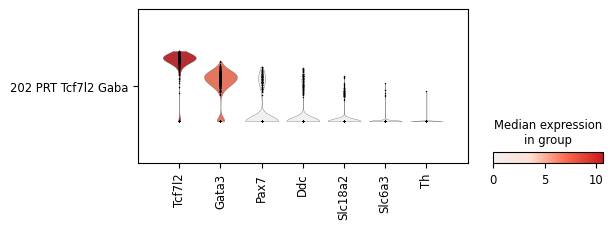

saving figure to file D:\scRNAseq\10X\DA136\SeuratAnalysis_2024-09-03\Figures\Figure3_MausComparison\stacked_violin_DMX_mouse.svg


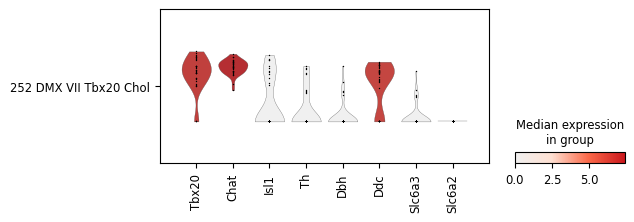

saving figure to file D:\scRNAseq\10X\DA136\SeuratAnalysis_2024-09-03\Figures\Figure3_MausComparison\stacked_violin_otp_mouse1.svg


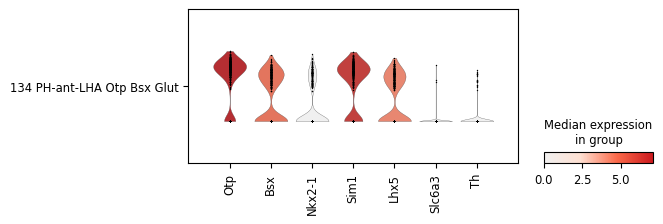

saving figure to file D:\scRNAseq\10X\DA136\SeuratAnalysis_2024-09-03\Figures\Figure3_MausComparison\stacked_violin_otp_mouse2.svg


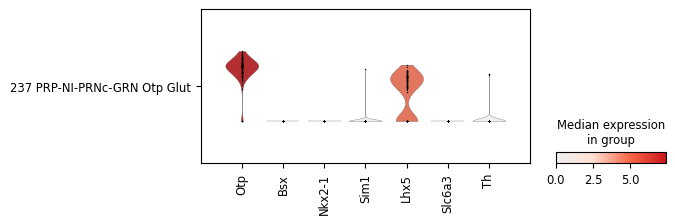

saving figure to file D:\scRNAseq\10X\DA136\SeuratAnalysis_2024-09-03\Figures\Figure3_MausComparison\stacked_violin_OB_mouse.svg


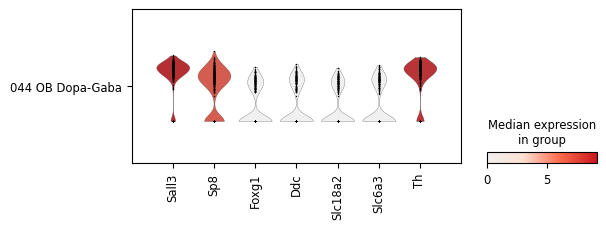

In [38]:
# VlnPlots of normalized expression of selected genes expressed in potential homologous zebrafish and mouse CA groups

cmap = LinearSegmentedColormap.from_list(
    "expr_red",
    ["#f0f0f0", "#fee0d2", "#fb6a4a", "#cb181d"]
)

genes = ["Tcf7l2", "Gata3", "Pax7", "Ddc", "Slc18a2", "Slc6a3", "Th"]





sc.pl.stacked_violin(
    adata[adata.obs["subclass"] == "202 PRT Tcf7l2 Gaba"],
    var_names=genes,
    groupby="subclass",
    stripplot=True,               
    save=r"PrT_mouse.svg",
    figsize=(6,2),
    cmap = cmap)


genes = ["Tbx20", "Chat", "Isl1", "Th", "Dbh", "Ddc", "Slc6a3", "Slc6a2" ]

sc.pl.stacked_violin(
    adata[adata.obs["subclass"] == "252 DMX VII Tbx20 Chol"],
    var_names=genes,
    groupby="subclass",
    stripplot=True,               
    save="DMX_mouse.svg",
    figsize=(6,2),
    cmap = cmap)
genes = ["Otp", "Bsx", "Nkx2-1", "Sim1", "Lhx5", "Slc6a3", "Th"]

sc.pl.stacked_violin(
    adata[adata.obs["subclass"] == "134 PH-ant-LHA Otp Bsx Glut"],
    var_names=genes,
    groupby="subclass",
    stripplot=True,               
    save="otp_mouse1.svg",
    figsize=(6,2),
    cmap = cmap)

sc.pl.stacked_violin(
    adata[adata.obs["subclass"] == "237 PRP-NI-PRNc-GRN Otp Glut"],
    var_names=genes,
    groupby="subclass",
    stripplot=True,               
    save="otp_mouse2.svg",
    figsize=(6,2),
    cmap = cmap)


genes = ["Sall3", "Sp8", "Foxg1", "Ddc", "Slc18a2", "Slc6a3", "Th"]


sc.pl.stacked_violin(
    adata[adata.obs["subclass"] == "044 OB Dopa-Gaba"],
    var_names=genes,
    groupby="subclass",
    stripplot=True,               
    save=r"OB_mouse.svg",
    figsize=(6,2),
    cmap = cmap)



# 7. Read in AnnData conversted zebrafish CA cluster data

In [39]:
adata_zf = sc.read_h5ad(filename=r"D:\scRNAseq\10X\DA136\SeuratAnalysis_2024-09-03\OwnData_anndata_file\own_seurat_annotated.h5ad")

saving figure to file D:\scRNAseq\10X\DA136\SeuratAnalysis_2024-09-03\Figures\Figure3_MausComparison\stacked_violin_PretectumZebrafish.svg


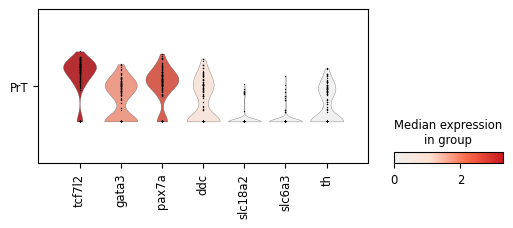

saving figure to file D:\scRNAseq\10X\DA136\SeuratAnalysis_2024-09-03\Figures\Figure3_MausComparison\stacked_violin_DMX_zebrafish.svg


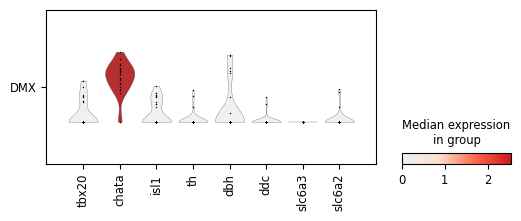

saving figure to file D:\scRNAseq\10X\DA136\SeuratAnalysis_2024-09-03\Figures\Figure3_MausComparison\stacked_violin_otp_zebrafish.svg


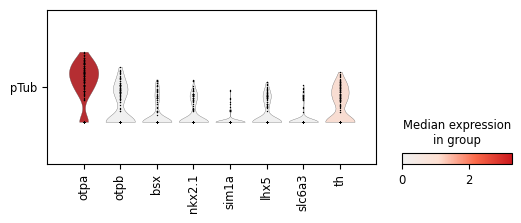

saving figure to file D:\scRNAseq\10X\DA136\SeuratAnalysis_2024-09-03\Figures\Figure3_MausComparison\stacked_violin_OBZebrafish.svg


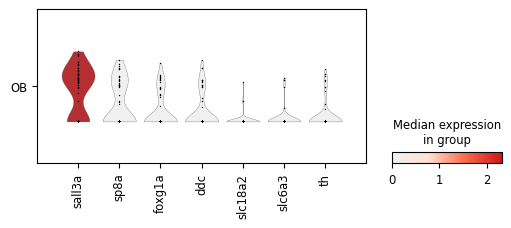

In [40]:
# VlnPlots of normalized expression of selected genes expressed in potential homologous zebrafish and mouse CA groups

genes = ["tcf7l2", "gata3", "pax7a", "ddc", "slc18a2", "slc6a3", "th"]


sc.pl.stacked_violin(
    adata_zf[adata_zf.obs["Fig1_annotation"] == "PrT"],
    var_names=genes,
    stripplot=True,
    groupby="Fig1_annotation", 
    save="PretectumZebrafish.svg",
    figsize=(6,2),
    cmap = cmap
    
)


genes = ["tbx20", "chata", "isl1", "th", "dbh", "ddc", "slc6a3", "slc6a2"]

sc.pl.stacked_violin(
    adata_zf[adata_zf.obs["Fig1_annotation"] == "DMX"],
    var_names=genes,
    groupby="Fig1_annotation",
    stripplot=True,               
    save="DMX_zebrafish.svg",
    figsize=(6,2),
    cmap = cmap
)


genes = ["otpa", "otpb", "bsx", "nkx2.1", "sim1a", "lhx5", "slc6a3", "th"]

sc.pl.stacked_violin(
    adata_zf[adata_zf.obs["Fig1_annotation"] == "pTub"],
    var_names=genes,
    groupby="Fig1_annotation",
    stripplot=True,               
    save="otp_zebrafish.svg",
    figsize=(6,2),
    cmap = cmap
)


genes = ["sall3a", "sp8a", "foxg1a", "ddc", "slc18a2", "slc6a3", "th"]


sc.pl.stacked_violin(
    adata_zf[adata_zf.obs["Fig1_annotation"] == "OB"],
    var_names=genes,
    stripplot=True,
    groupby="Fig1_annotation", 
    save="OBZebrafish.svg",
    figsize=(6,2),
    cmap = cmap
)


# 8. Session info

In [41]:
session_info.show()